In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import root_mean_squared_error as rme
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
exchange_rate = yf.download("USDINR=X", start="2019-04-08", end="2026-04-09")

In [ ]:
closing_price = yf.download("^NSEI",start="2019-04-08", end="2026-04-09" )

In [ ]:
gold_rate  = yf.download("GC=F",start="2019-04-08", end="2026-04-09" )

In [ ]:
downloaded_data = pd.concat([gold_rate['Close'], closing_price['Close'], exchange_rate['Close']], axis=1)

In [ ]:
downloaded_data

In [ ]:
downloaded_data.to_csv("/content/yfinance_data.csv", index=True)

In [ ]:
data = pd.read_csv('/content/gold_data.csv')

In [ ]:
data

,date,gold_rate_usd,gold_rate,exchange_rate,inflation_rate,policy_repo_rate,closing_price
0,2019-04-08 00:00:00,1297.1,89707.44,69.16,2.99,6.00,11604.50
1,2019-04-09 00:00:00,1303.5,90661.68,69.55,2.99,6.00,11671.95
2,2019-04-10 00:00:00,1309.1,90670.62,69.26,2.99,6.00,11584.30
3,2019-04-11 00:00:00,1288.6,89094.06,69.14,2.99,6.00,11596.70
4,2019-04-12 00:00:00,1290.6,89606.36,69.43,2.99,6.00,11643.45
...,...,...,...,...,...,...,...
2553,2026-04-04 00:00:00,4651.5,432466.71,92.97,3.21,5.25,22713.10
2554,2026-04-05 00:00:00,4651.5,432466.71,92.97,3.21,5.25,22713.10
2555,2026-04-06 00:00:00,4656.8,432947.34,92.97,3.21,5.25,22968.25
2556,2026-04-07 00:00:00,4657.1,432256.18,92.82,3.21,5.25,23123.65


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2558 entries, 0 to 2557
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              2558 non-null   object 
 1   gold_rate_usd     2558 non-null   float64
 2   gold_rate         2558 non-null   float64
 3   exchange_rate     2558 non-null   float64
 4   inflation_rate    2558 non-null   float64
 5   policy_repo_rate  2558 non-null   float64
 6   closing_price     2558 non-null   float64
dtypes: float64(6), object(1)
memory usage: 140.0+ KB


In [ ]:
data['date'] = pd.to_datetime(data['date'])

In [ ]:
data.index = data['date']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-04-08 to 2026-04-08
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2558 non-null   datetime64[ns]
 1   gold_rate_usd     2558 non-null   float64       
 2   gold_rate         2558 non-null   float64       
 3   exchange_rate     2558 non-null   float64       
 4   inflation_rate    2558 non-null   float64       
 5   policy_repo_rate  2558 non-null   float64       
 6   closing_price     2558 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 159.9 KB


In [ ]:
data.drop(columns=['date', 'gold_rate_usd'], inplace = True)

In [ ]:
data

,gold_rate,exchange_rate,inflation_rate,policy_repo_rate,closing_price
date,,,,,
2019-04-08,89707.44,69.16,2.99,6.00,11604.50
2019-04-09,90661.68,69.55,2.99,6.00,11671.95
2019-04-10,90670.62,69.26,2.99,6.00,11584.30
2019-04-11,89094.06,69.14,2.99,6.00,11596.70
2019-04-12,89606.36,69.43,2.99,6.00,11643.45
...,...,...,...,...,...
2026-04-04,432466.71,92.97,3.21,5.25,22713.10
2026-04-05,432466.71,92.97,3.21,5.25,22713.10
2026-04-06,432947.34,92.97,3.21,5.25,22968.25


In [ ]:
data.isnull().sum()

,0
gold_rate,0
exchange_rate,0
inflation_rate,0
policy_repo_rate,0
closing_price,0


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
gold_rate,2558.0,179820.303217,82299.335200,88245.69,133437.950,146372.770,200123.6950,489509.79
exchange_rate,2558.0,79.464816,6.067379,68.37,74.160,81.160,83.5675,94.78
inflation_rate,2558.0,5.001188,1.715937,0.25,3.735,5.220,6.3000,7.79
policy_repo_rate,2558.0,5.350430,0.998613,4.00,4.000,5.500,6.5000,6.50
closing_price,2558.0,18057.867944,5028.249469,7610.25,14018.500,17758.875,22819.6000,26328.55


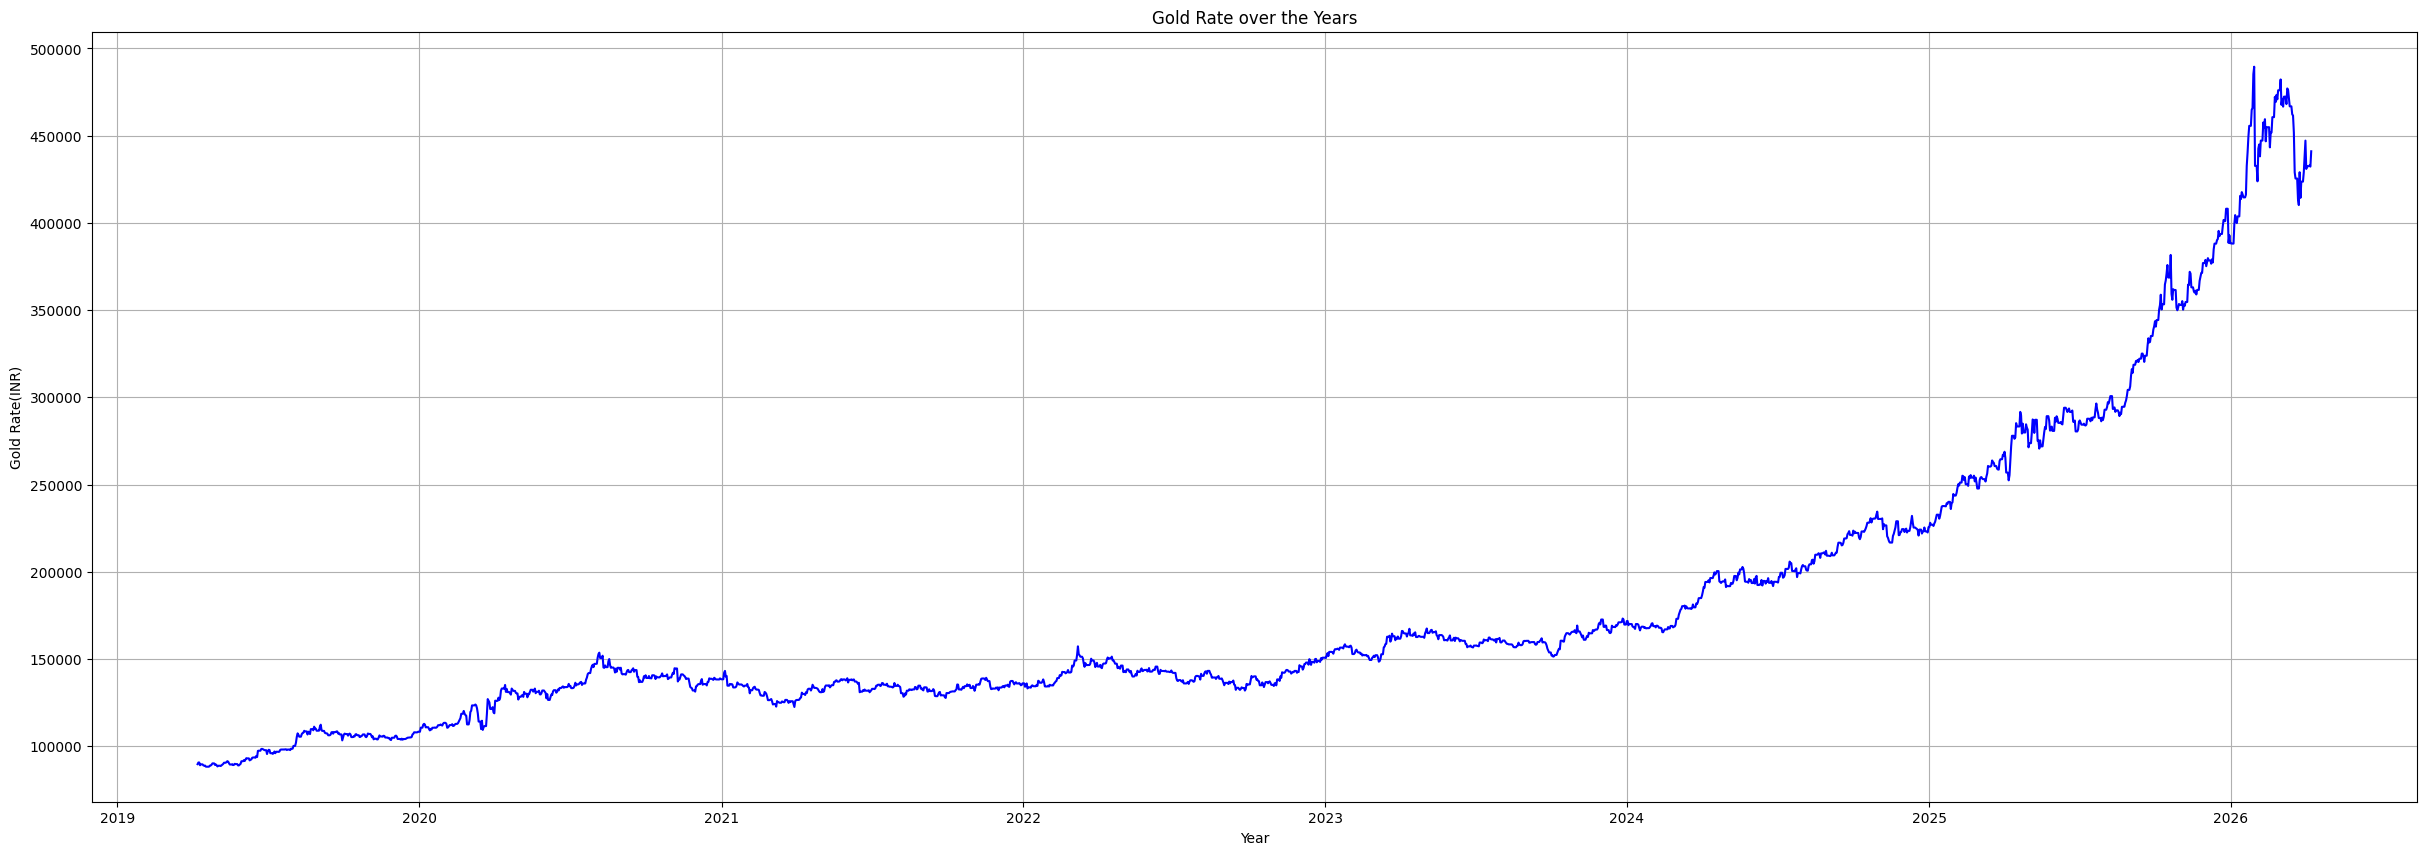

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(data['gold_rate'], color='blue')
plt.title('Gold Rate over the Years')
plt.xlabel('Year')
plt.ylabel("Gold Rate(INR)")
plt.grid()
plt.show()

In [ ]:
2558-365

2193

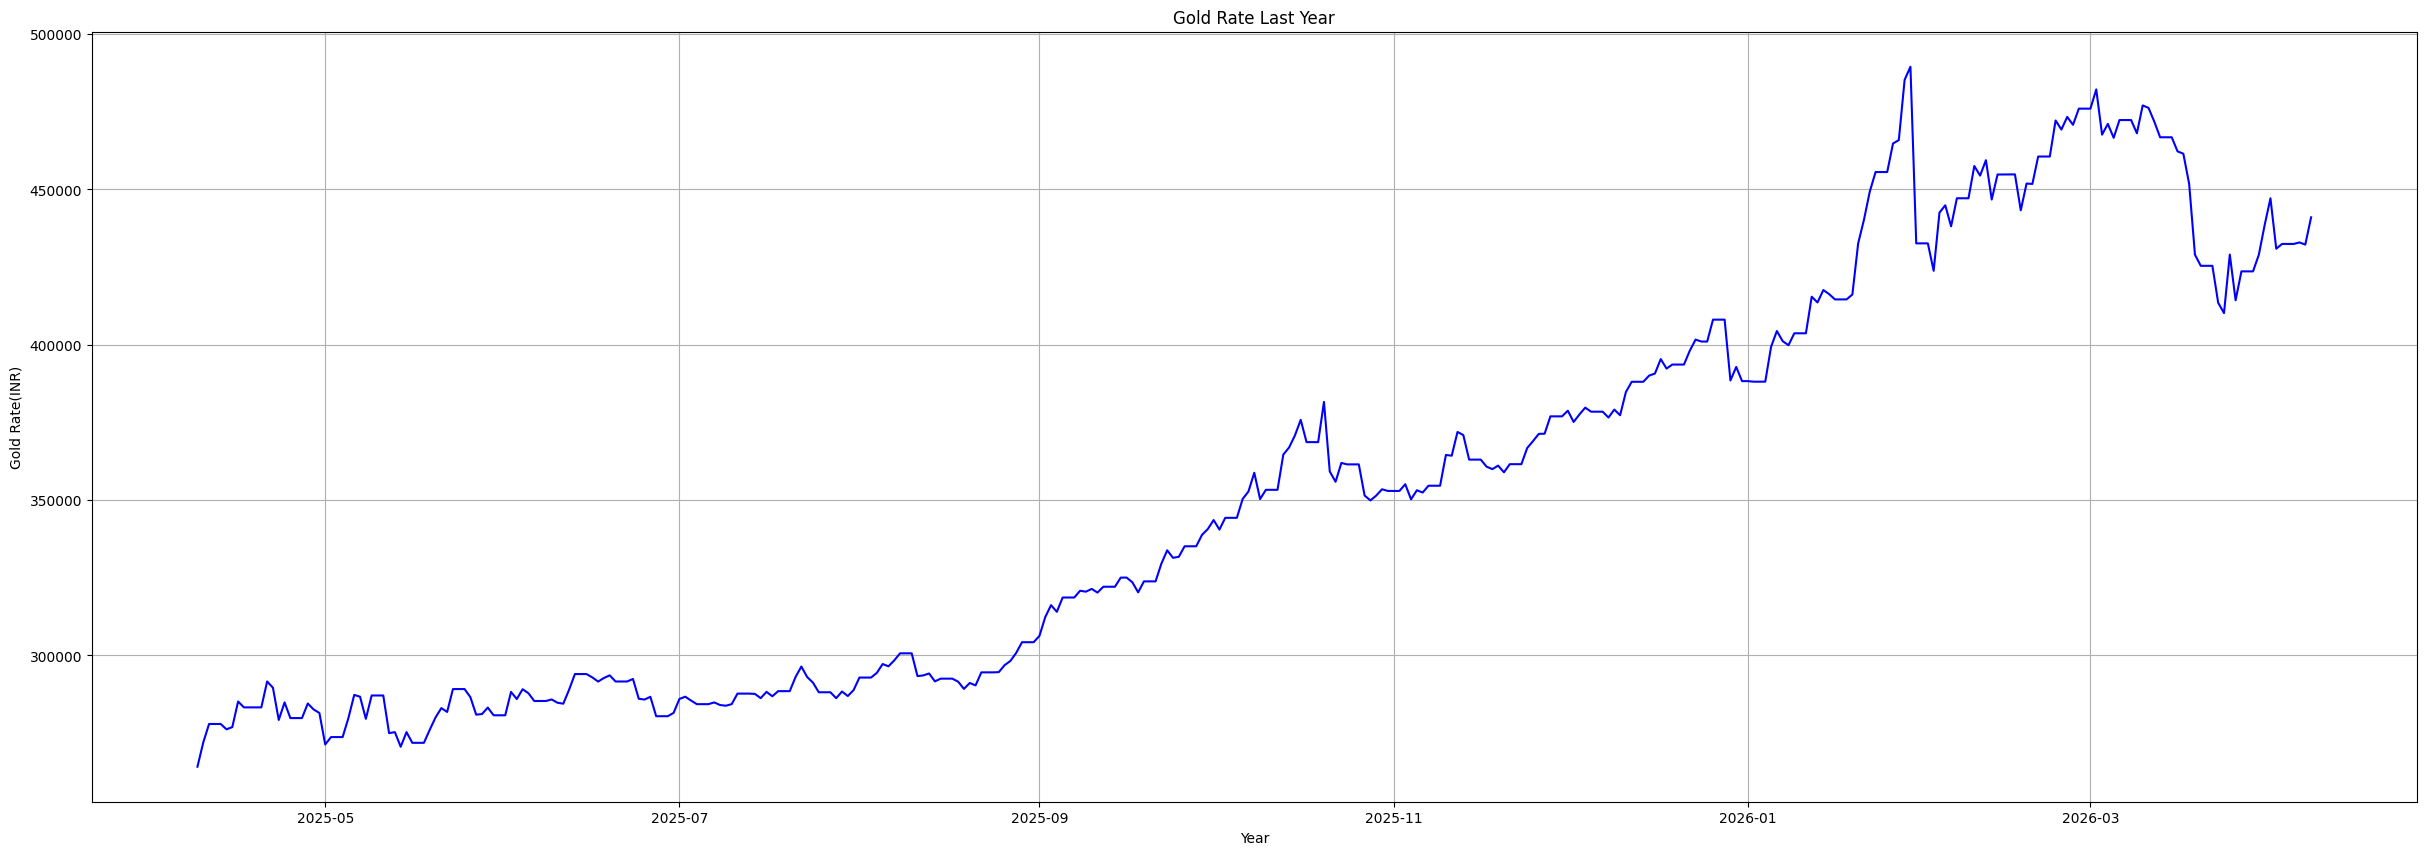

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(data['gold_rate'][2193:], color='blue')
plt.title('Gold Rate Last Year')
plt.xlabel('Year')
plt.ylabel("Gold Rate(INR)")
plt.grid()
plt.show()

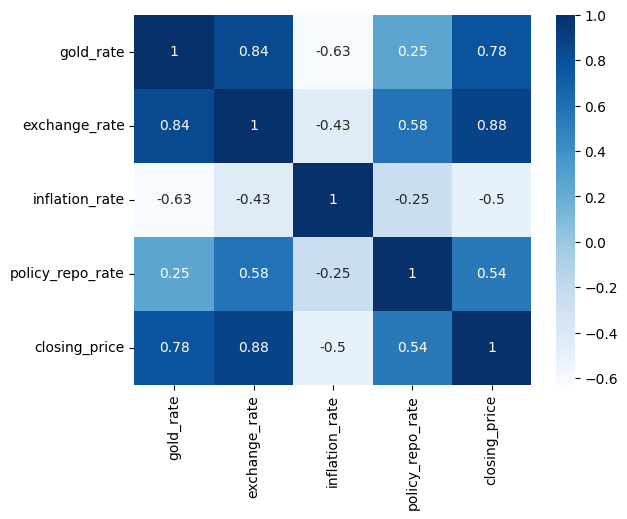

In [ ]:
sns.heatmap(data.corr(), annot=True, cmap='Blues')
plt.show()

In [ ]:
stl = STL(data['gold_rate'], period=365)
result_stl = stl.fit()

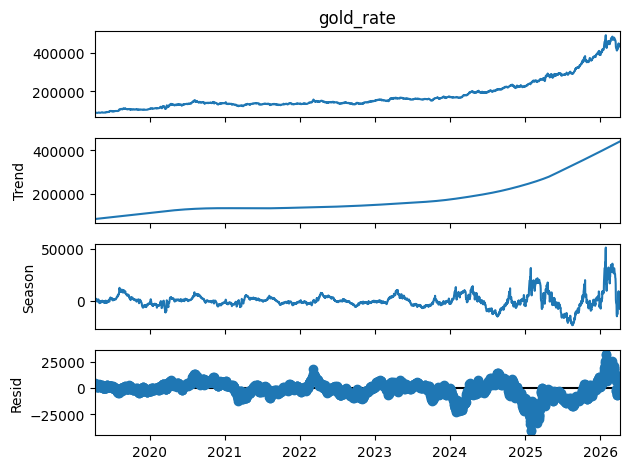

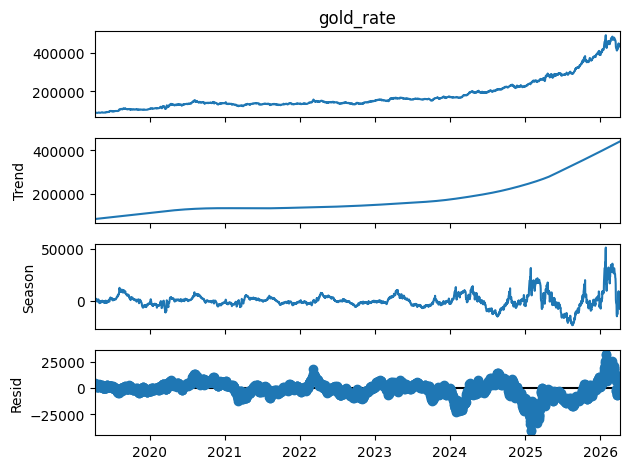

In [ ]:
result_stl.plot()

In [ ]:
stl1 = STL(data['gold_rate'], period=30)
result_stl1 = stl.fit()

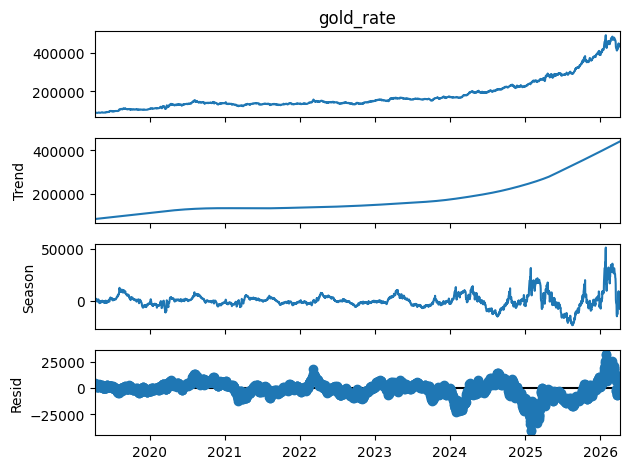

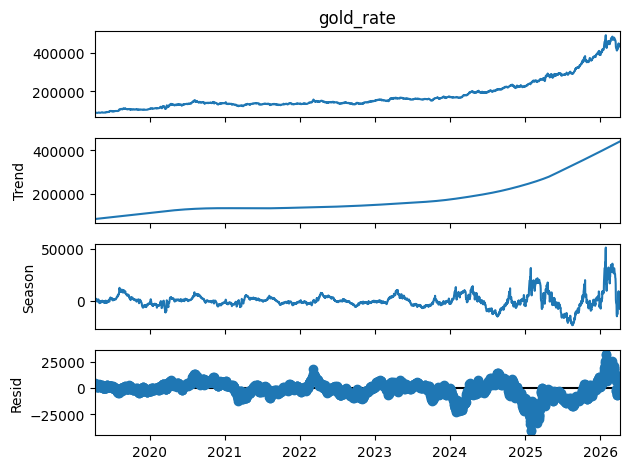

In [ ]:
result_stl1.plot()

In [ ]:
def adf_test(data):
    for col in data.columns:
        adf_result = adfuller(data[col])
        pvalue = adf_result[1]
        if pvalue < 0.05:
            print(f"Col:{col} is stationary")
            print(f"pvalue: {pvalue}")
        else:
            print(f"Col:{col} is not stationary")
            print(f"pvalue: {pvalue}")
        print("************")

In [ ]:
adf_test(data)

Col:gold_rate is not stationary
pvalue: 1.0
************
Col:exchange_rate is not stationary
pvalue: 0.9455594380805437
************
Col:inflation_rate is not stationary
pvalue: 0.21094787574496487
************
Col:policy_repo_rate is not stationary
pvalue: 0.7805617309627848
************
Col:closing_price is not stationary
pvalue: 0.8240891591871597
************


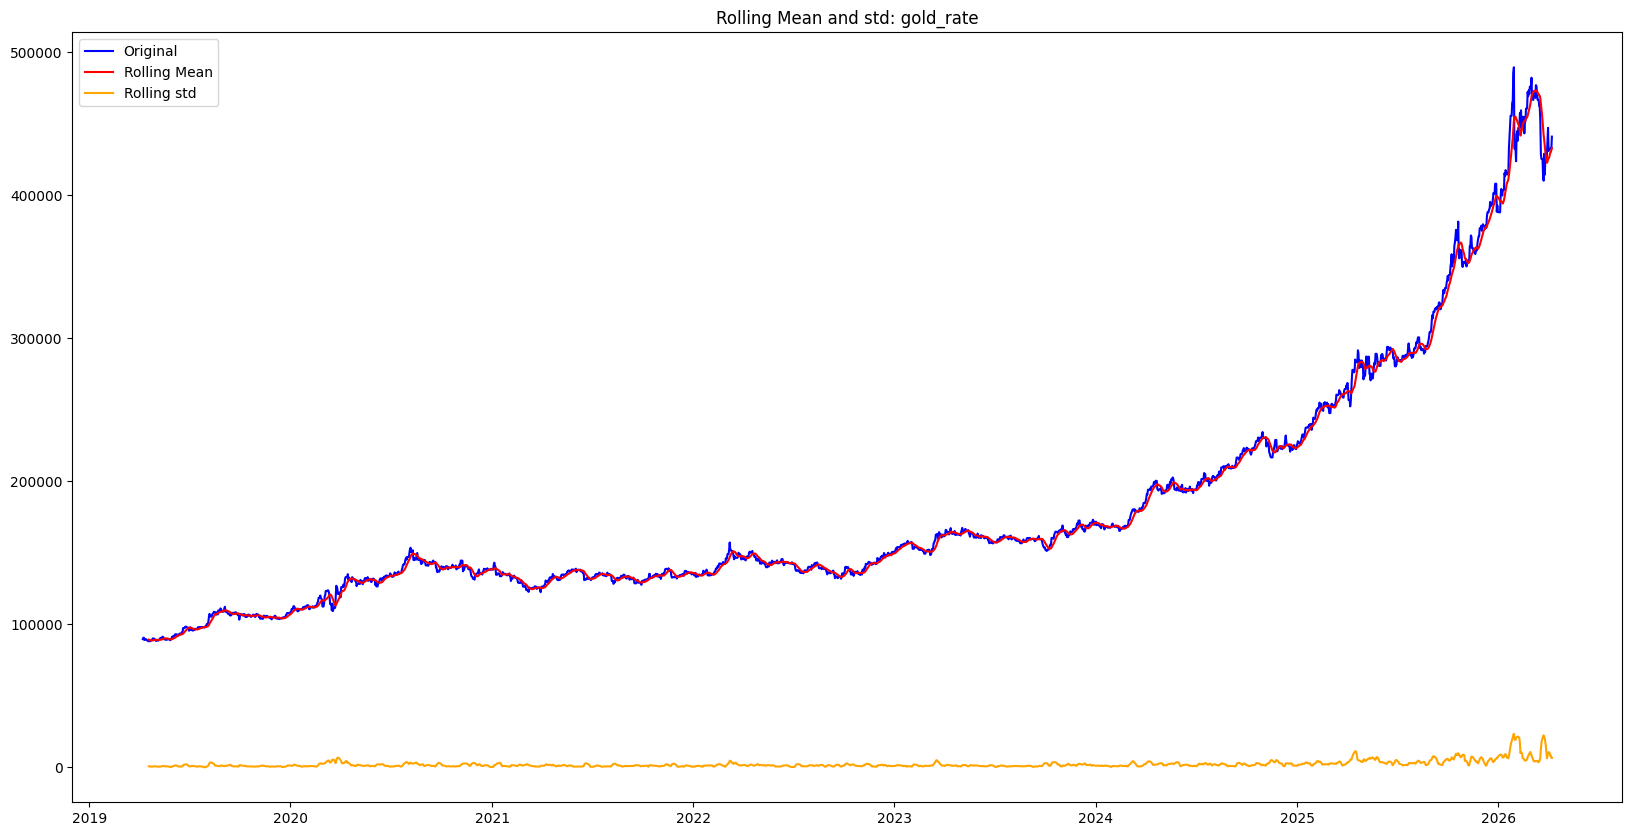

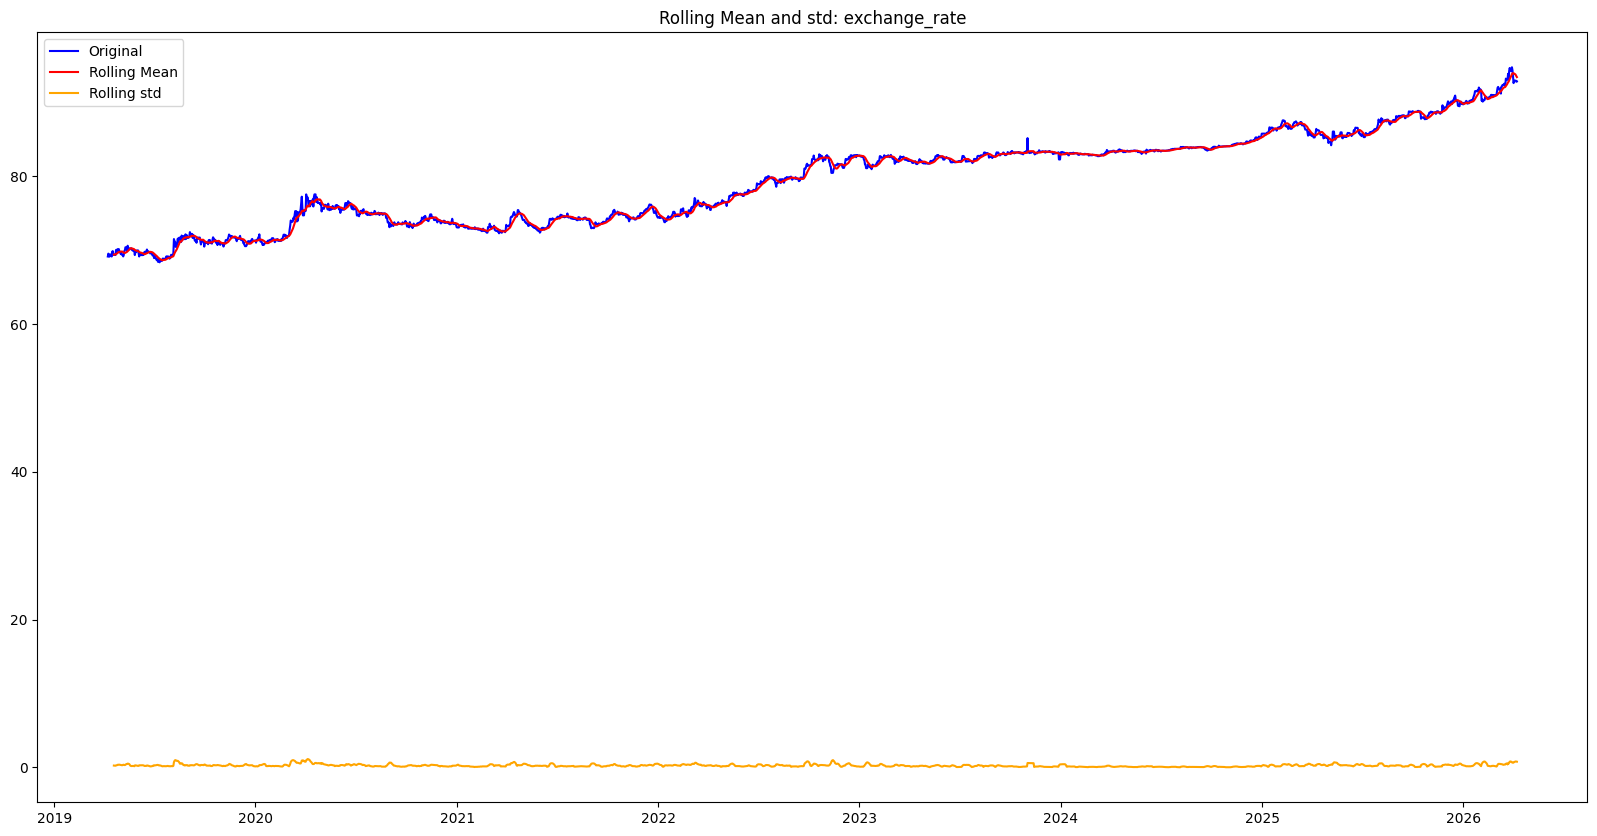

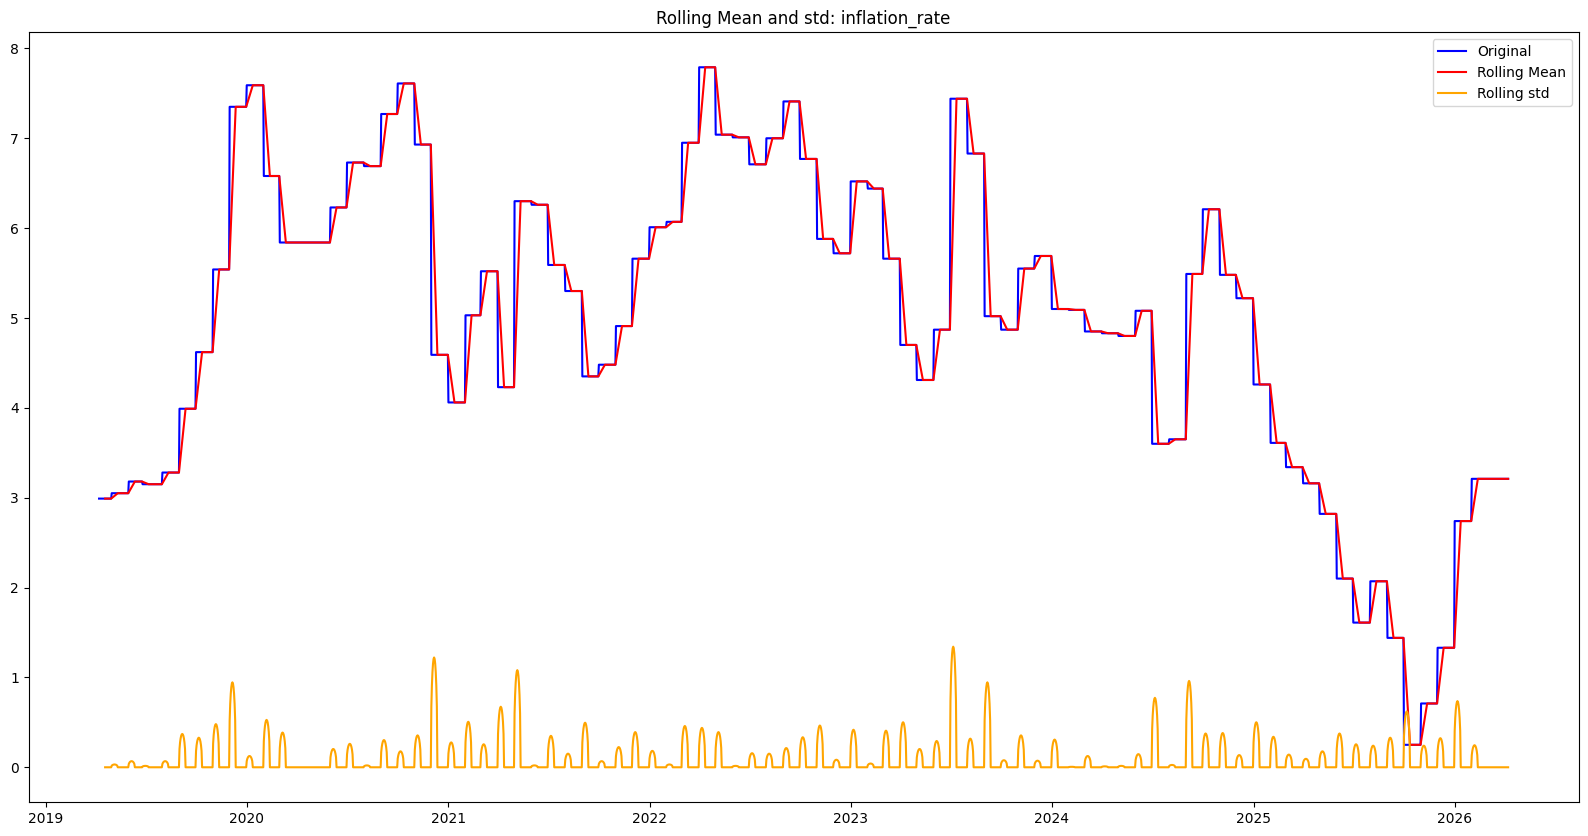

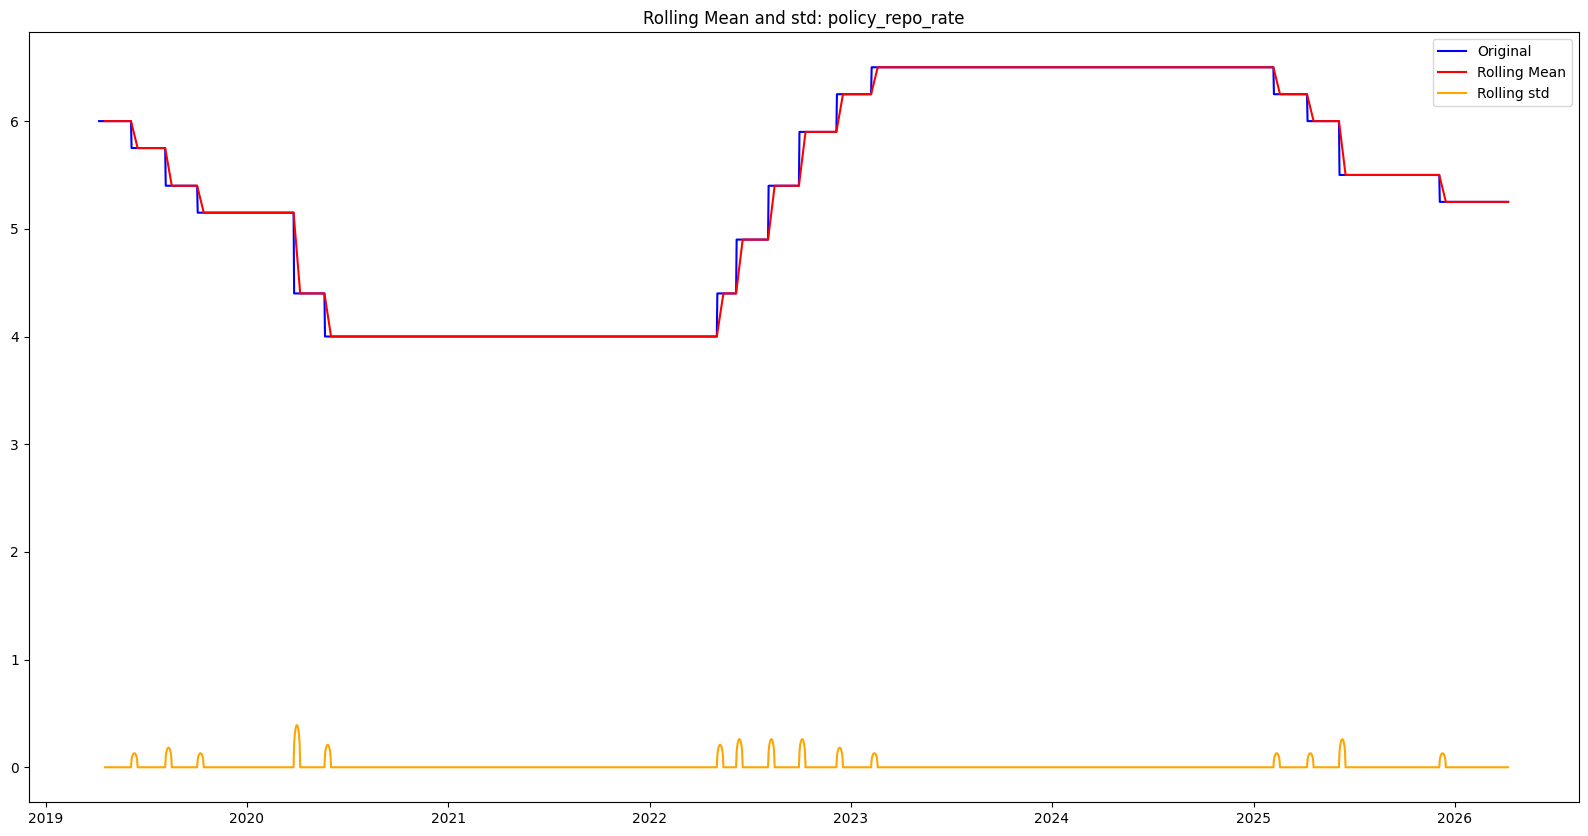

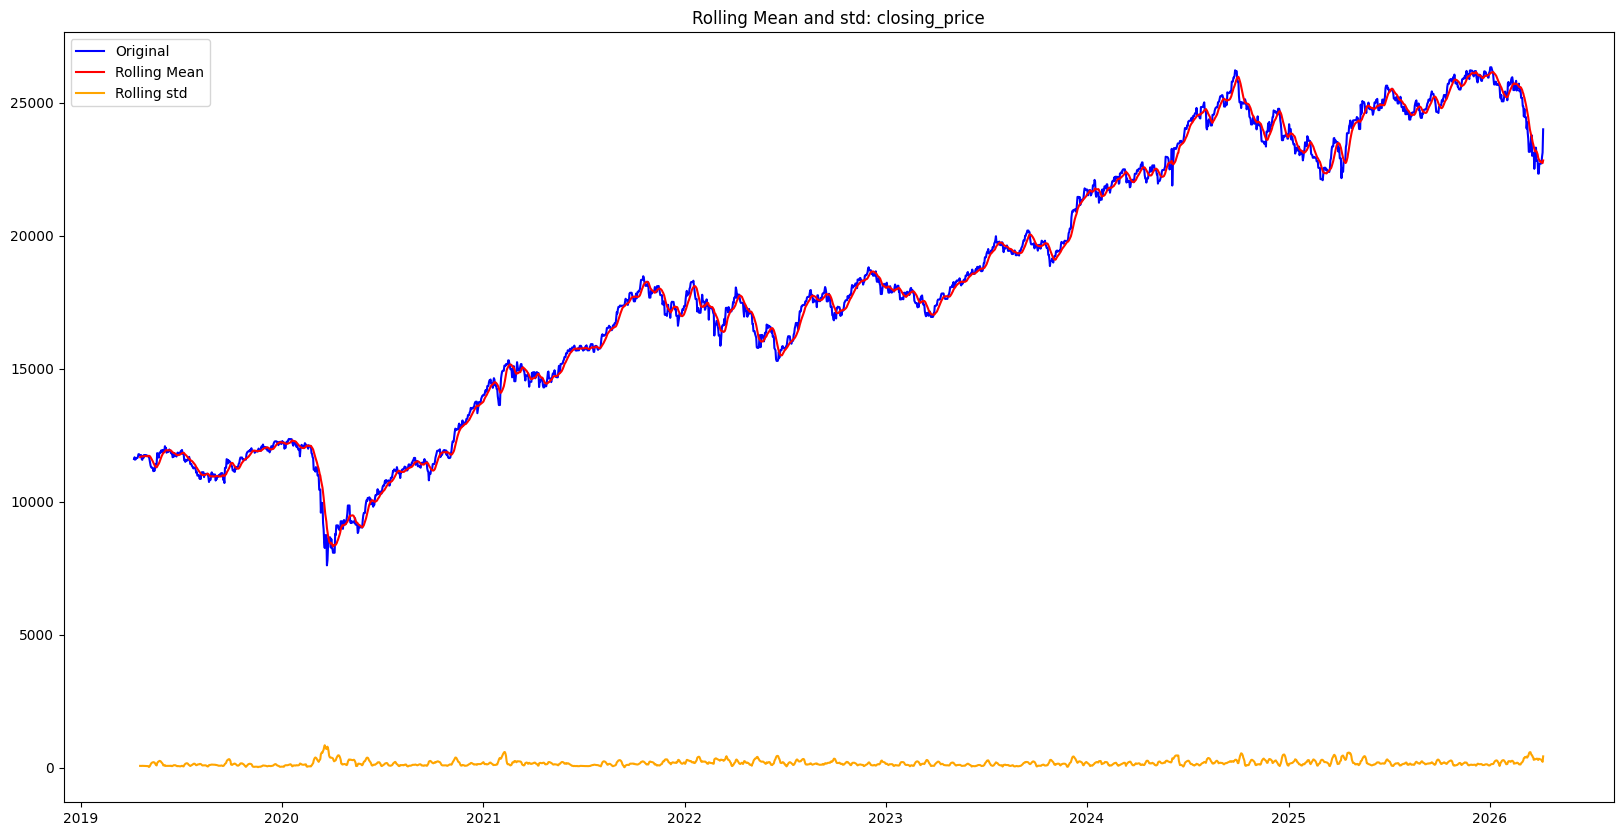

In [ ]:
for i in data.columns:
    mean = data[i].rolling(window=12).mean()
    std = data[i].rolling(window=12).std()
    plt.figure(figsize=(20,10))
    plt.plot(data[i], label="Original", color="blue")
    plt.plot(mean, label="Rolling Mean", color="red")
    plt.plot(std, label="Rolling std", color="orange")
    plt.title(f"Rolling Mean and std: {i}")
    plt.legend()
    plt.show()

In [ ]:
gold_log = np.log(data['gold_rate'])

In [ ]:
new_gold_rate = gold_log.diff()

In [ ]:
new_gold_rate.dropna(inplace=True)

In [ ]:
adfuller(new_gold_rate)

(np.float64(-19.83601138109861),
 0.0,
 7,
 2549,
 {'1%': np.float64(-3.432918025717116),
  '5%': np.float64(-2.862674549708125),
  '10%': np.float64(-2.567373963123101)},
 np.float64(-16126.997897518035))

In [ ]:
exchange_log = np.log(data['exchange_rate'])

In [ ]:
new_exchange_rate = exchange_log.diff()

In [ ]:
new_exchange_rate.dropna(inplace=True)

In [ ]:
adfuller(new_exchange_rate)

(np.float64(-12.98608541992848),
 np.float64(2.8764093711115653e-24),
 13,
 2543,
 {'1%': np.float64(-3.4329240908958814),
  '5%': np.float64(-2.8626772281377195),
  '10%': np.float64(-2.5673753891470175)},
 np.float64(-22213.601015722812))

In [ ]:
2.876409371112183e-24<0.05

True

In [ ]:
inf_log = np.log(data['inflation_rate'])

In [ ]:
new_inflation_rate = inf_log.diff()

In [ ]:
new_inflation_rate.dropna(inplace=True)

In [ ]:
adfuller(new_inflation_rate)

(np.float64(-50.53712902919654),
 0.0,
 0,
 2556,
 {'1%': np.float64(-3.4329109857007527),
  '5%': np.float64(-2.862671440775931),
  '10%': np.float64(-2.5673723078962385)},
 np.float64(-7663.450350450152))

In [ ]:
new_repo_rate = data['policy_repo_rate'].diff()

In [ ]:
new_repo_rate.dropna(inplace=True)
adfuller(new_repo_rate)

(np.float64(-50.54155990576269),
 0.0,
 0,
 2556,
 {'1%': np.float64(-3.4329109857007527),
  '5%': np.float64(-2.862671440775931),
  '10%': np.float64(-2.5673723078962385)},
 np.float64(-10315.586621822644))

In [ ]:
closing_log = np.log(data['closing_price'])

In [ ]:
new_closing_price = closing_log.diff()

In [ ]:
new_closing_price.dropna(inplace=True)
adfuller(new_closing_price)

(np.float64(-12.023075403439554),
 np.float64(2.9921131262891725e-22),
 14,
 2542,
 {'1%': np.float64(-3.4329251045454816),
  '5%': np.float64(-2.8626776757726495),
  '10%': np.float64(-2.567375627472622)},
 np.float64(-16531.82052754488))

In [ ]:
2.9921131262881413e-22<0.05

True

In [ ]:
new_data = pd.concat([new_gold_rate, new_exchange_rate, new_inflation_rate, new_repo_rate, new_closing_price], axis=1)

In [ ]:
new_data

,gold_rate,exchange_rate,inflation_rate,policy_repo_rate,closing_price
date,,,,,
2019-04-09,0.010581,0.005623,0.0,0.0,0.005796
2019-04-10,0.000099,-0.004178,0.0,0.0,-0.007538
2019-04-11,-0.017541,-0.001734,0.0,0.0,0.001070
2019-04-12,0.005734,0.004186,0.0,0.0,0.004023
2019-04-13,0.000000,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...
2026-04-04,0.000000,0.000000,0.0,0.0,0.000000
2026-04-05,0.000000,0.000000,0.0,0.0,0.000000
2026-04-06,0.001111,0.000000,0.0,0.0,0.011171


In [ ]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-04-09 to 2026-04-08
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gold_rate         2557 non-null   float64
 1   exchange_rate     2557 non-null   float64
 2   inflation_rate    2557 non-null   float64
 3   policy_repo_rate  2557 non-null   float64
 4   closing_price     2557 non-null   float64
dtypes: float64(5)
memory usage: 119.9 KB


In [ ]:
new_data.dropna(inplace=True)

In [ ]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2019-04-09 to 2026-04-08
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gold_rate         2557 non-null   float64
 1   exchange_rate     2557 non-null   float64
 2   inflation_rate    2557 non-null   float64
 3   policy_repo_rate  2557 non-null   float64
 4   closing_price     2557 non-null   float64
dtypes: float64(5)
memory usage: 119.9 KB


In [ ]:
new_data.describe().T

,count,mean,std,min,25%,50%,75%,max
gold_rate,2557.0,0.000623,0.009961,-0.123474,-0.002148,0.0,0.004447,0.069396
exchange_rate,2557.0,0.000115,0.003055,-0.023036,-0.000720,0.0,0.000838,0.029435
inflation_rate,2557.0,0.000028,0.052859,-1.750937,0.000000,0.0,0.000000,1.043804
policy_repo_rate,2557.0,-0.000293,0.031289,-0.750000,0.000000,0.0,0.000000,0.500000
closing_price,2557.0,0.000284,0.009304,-0.139038,-0.001691,0.0,0.003318,0.084003


Stationarity Test on Transformed data

In [ ]:
adf_test(new_data)

Col:gold_rate is stationary
pvalue: 0.0
************
Col:exchange_rate is stationary
pvalue: 2.8764093711115653e-24
************
Col:inflation_rate is stationary
pvalue: 0.0
************
Col:policy_repo_rate is stationary
pvalue: 0.0
************
Col:closing_price is stationary
pvalue: 2.9921131262891725e-22
************


Visualizing the data after Transformation

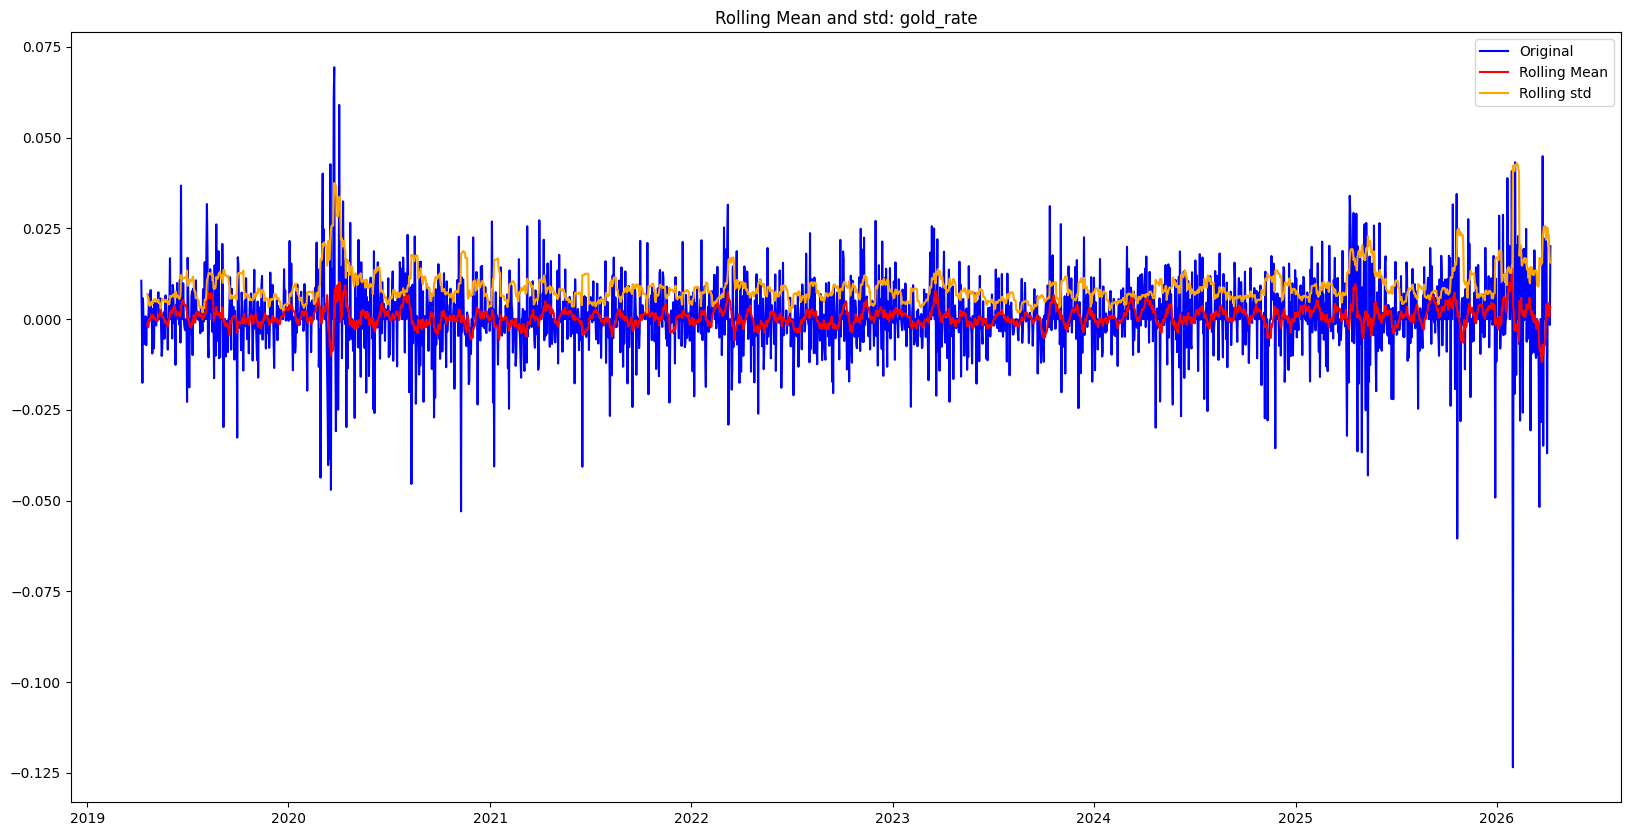

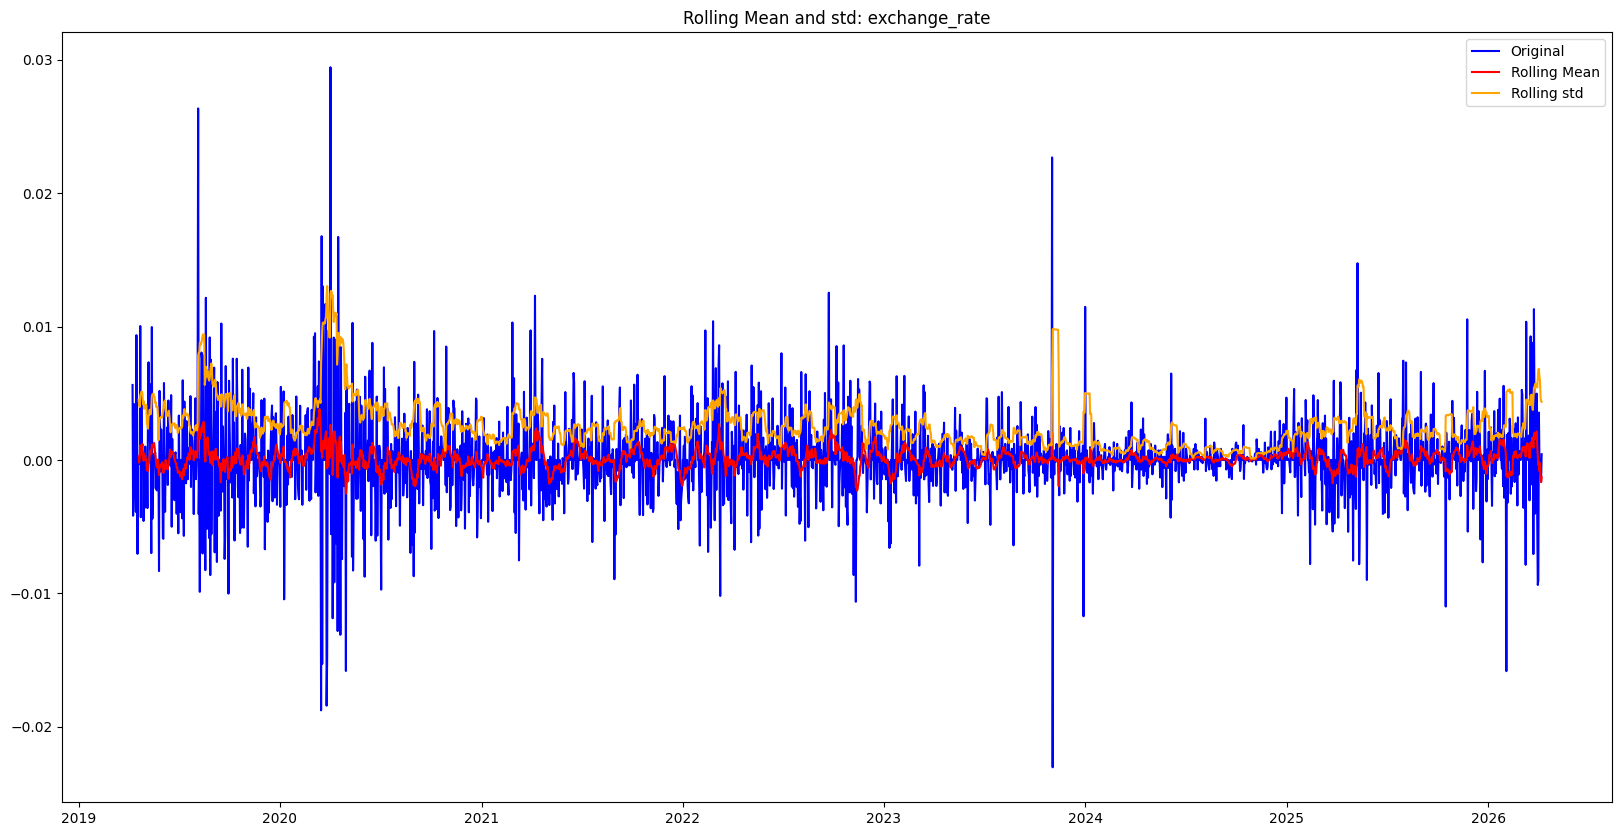

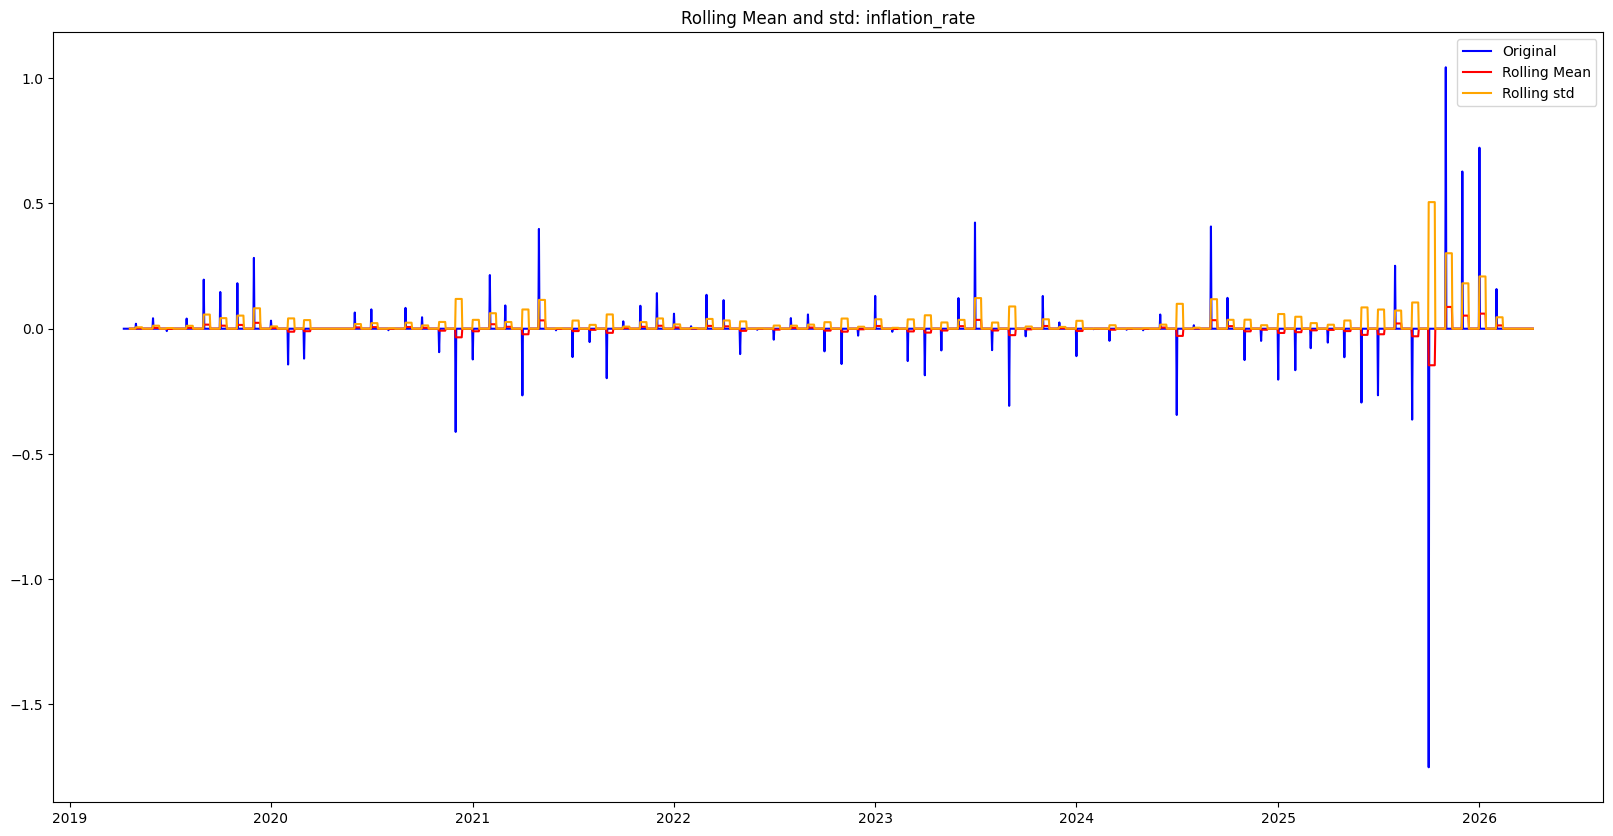

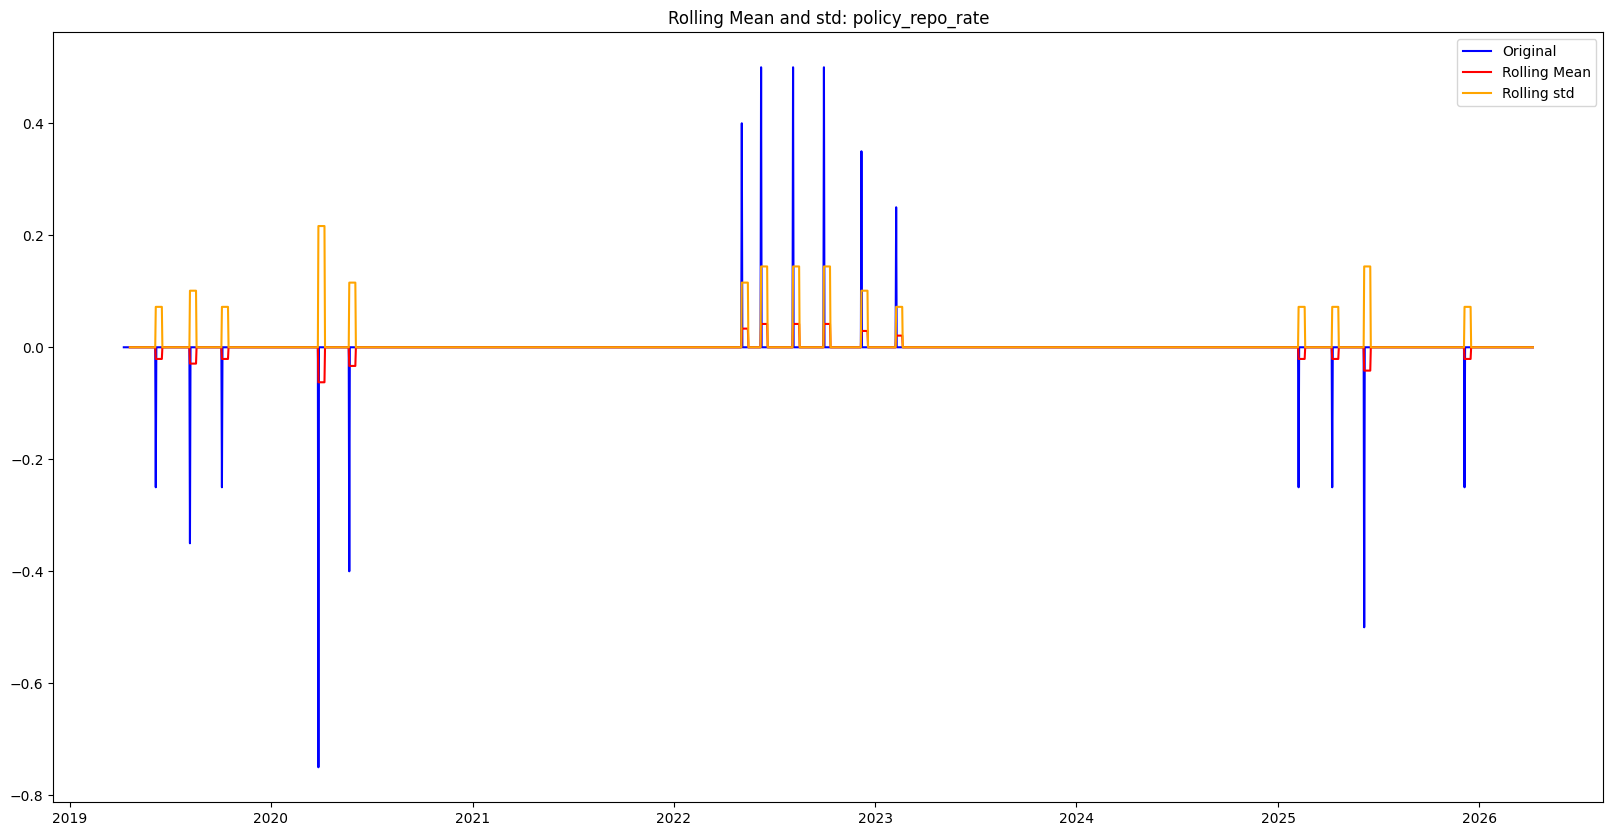

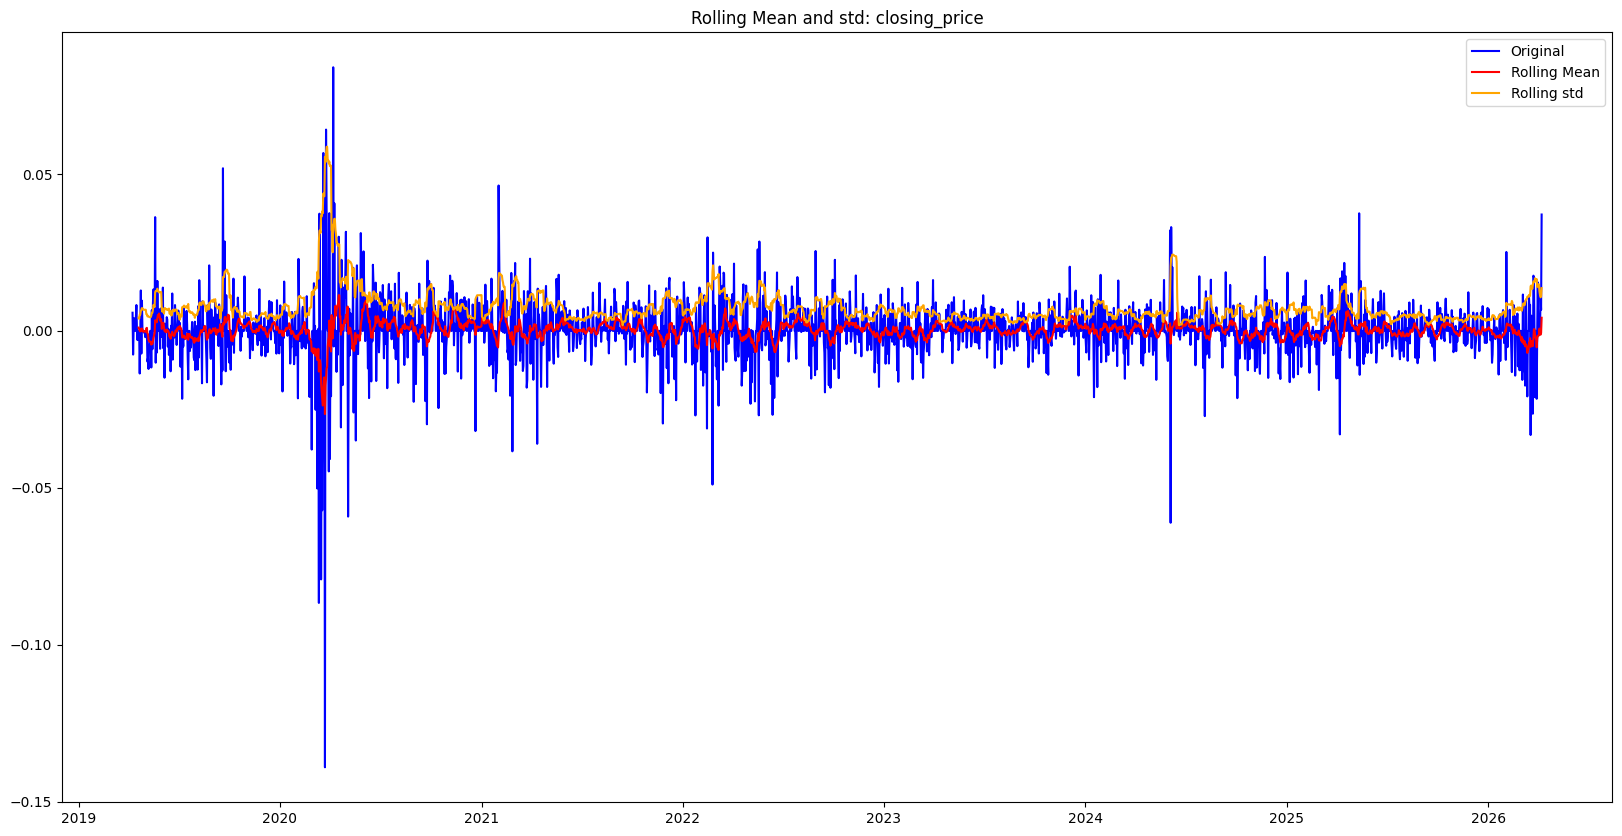

In [ ]:
for col in new_data.columns:
    mean = new_data[col].rolling(window=12).mean()
    std = new_data[col].rolling(window=12).std()
    plt.figure(figsize=(20,10))
    plt.plot(new_data[col], label="Original", color="blue")
    plt.plot(mean, label="Rolling Mean", color="red")
    plt.plot(std, label="Rolling std", color="orange")
    plt.title(f"Rolling Mean and std: {col}")
    plt.legend()
    plt.show()

In [ ]:
stl = STL(new_data['gold_rate'], period=365)
result_stl = stl.fit()

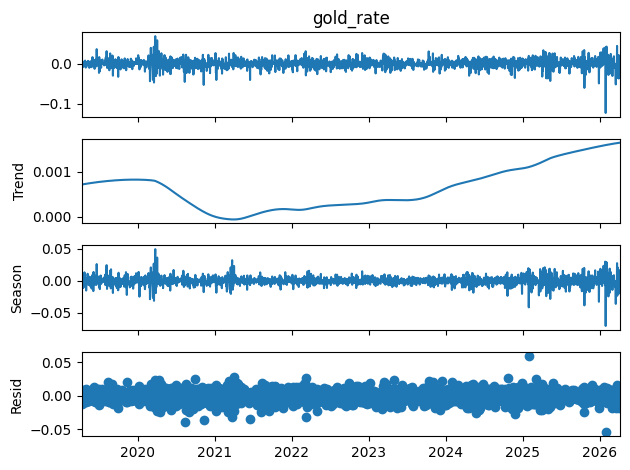

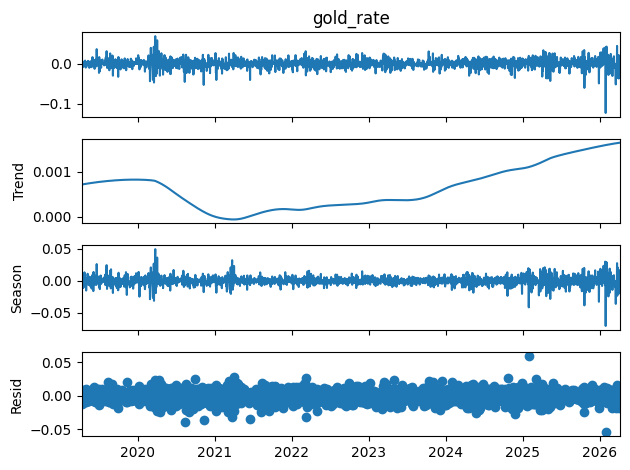

In [ ]:
result_stl.plot()

In [ ]:
stl1 = STL(new_data['gold_rate'], period=30)
result_stl = stl1.fit()

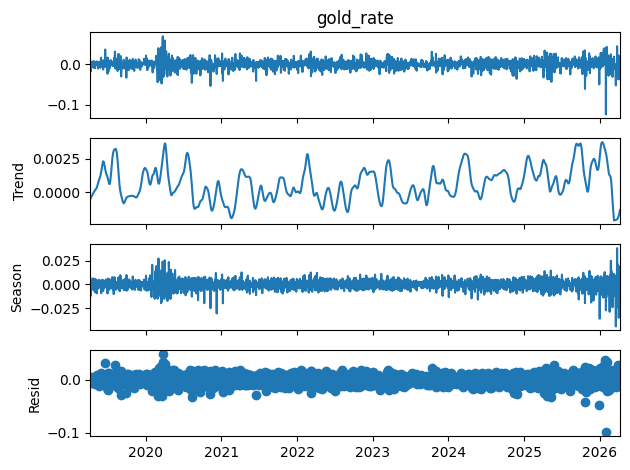

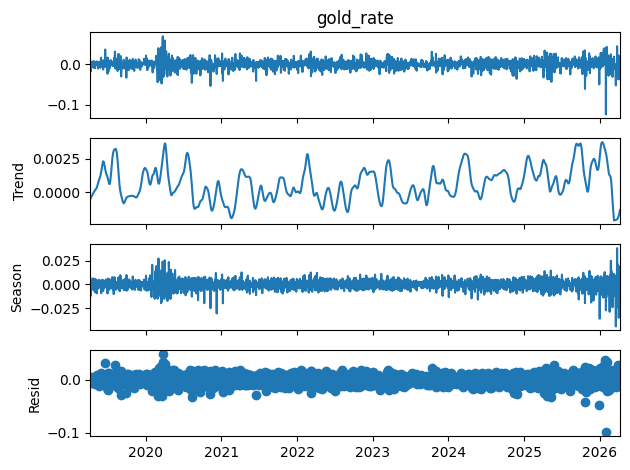

In [ ]:
result_stl.plot()

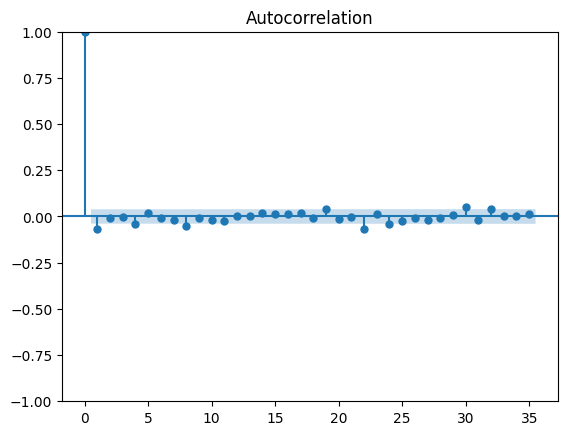

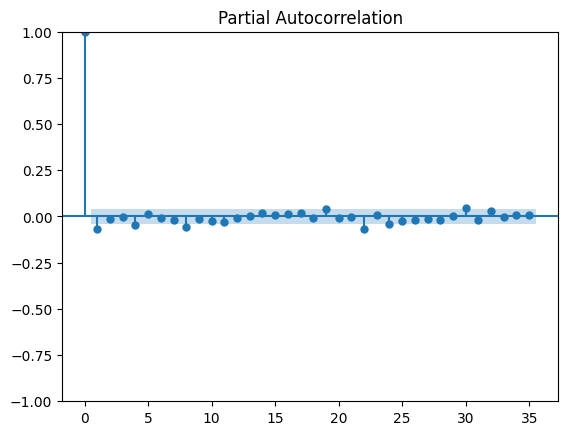

In [ ]:
acf = plot_acf(new_data['gold_rate'])
pacf = plot_pacf(new_data['gold_rate'])

In [ ]:
exogenous_var = new_data.iloc[:,1:]
target_var = new_data.iloc[:,0]

In [ ]:
exogenous_var

,exchange_rate,inflation_rate,policy_repo_rate,closing_price
date,,,,
2019-04-09,0.005623,0.0,0.0,0.005796
2019-04-10,-0.004178,0.0,0.0,-0.007538
2019-04-11,-0.001734,0.0,0.0,0.001070
2019-04-12,0.004186,0.0,0.0,0.004023
2019-04-13,0.000000,0.0,0.0,0.000000
...,...,...,...,...
2026-04-04,0.000000,0.0,0.0,0.000000
2026-04-05,0.000000,0.0,0.0,0.000000
2026-04-06,0.000000,0.0,0.0,0.011171


In [ ]:
ratio = round(len(new_data)*0.70)
x_train = exogenous_var[:ratio]
x_test = exogenous_var[ratio:]
y_train = target_var[:ratio]
y_test = target_var[ratio:]

In [ ]:
ratio

1790

In [ ]:
x_test

,exchange_rate,inflation_rate,policy_repo_rate,closing_price
date,,,,
2024-03-03,0.000000,0.0,0.0,0.000000
2024-03-04,-0.000724,0.0,0.0,0.002988
2024-03-05,0.000724,0.0,0.0,-0.002203
2024-03-06,-0.000362,0.0,0.0,0.005253
2024-03-07,-0.000724,0.0,0.0,0.000867
...,...,...,...,...
2026-04-04,0.000000,0.0,0.0,0.000000
2026-04-05,0.000000,0.0,0.0,0.000000
2026-04-06,0.000000,0.0,0.0,0.011171


In [ ]:
x_train

,exchange_rate,inflation_rate,policy_repo_rate,closing_price
date,,,,
2019-04-09,0.005623,0.000000,0.0,0.005796
2019-04-10,-0.004178,0.000000,0.0,-0.007538
2019-04-11,-0.001734,0.000000,0.0,0.001070
2019-04-12,0.004186,0.000000,0.0,0.004023
2019-04-13,0.000000,0.000000,0.0,0.000000
...,...,...,...,...
2024-02-27,-0.000362,0.000000,0.0,0.003443
2024-02-28,0.001206,0.000000,0.0,-0.011198
2024-02-29,-0.000482,0.000000,0.0,0.001441


In [ ]:
y_train

,gold_rate
date,
2019-04-09,0.010581
2019-04-10,0.000099
2019-04-11,-0.017541
2019-04-12,0.005734
2019-04-13,0.000000
...,...
2024-02-27,0.002348
2024-02-28,0.000669
2024-02-29,0.005790


In [ ]:
y_test

,gold_rate
date,
2024-03-03,0.000000
2024-03-04,0.013875
2024-03-05,0.008210
2024-03-06,0.007534
2024-03-07,0.002781
...,...
2026-04-04,0.000000
2026-04-05,0.000000
2026-04-06,0.001111


In [ ]:
import itertools

In [ ]:
p = range(9)
d = range(1)
q = range(9)

combinations = list(itertools.product(p,d,q))
combinations

[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 0, 3),
 (0, 0, 4),
 (0, 0, 5),
 (0, 0, 6),
 (0, 0, 7),
 (0, 0, 8),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 0, 4),
 (1, 0, 5),
 (1, 0, 6),
 (1, 0, 7),
 (1, 0, 8),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 0, 4),
 (2, 0, 5),
 (2, 0, 6),
 (2, 0, 7),
 (2, 0, 8),
 (3, 0, 0),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 0, 4),
 (3, 0, 5),
 (3, 0, 6),
 (3, 0, 7),
 (3, 0, 8),
 (4, 0, 0),
 (4, 0, 1),
 (4, 0, 2),
 (4, 0, 3),
 (4, 0, 4),
 (4, 0, 5),
 (4, 0, 6),
 (4, 0, 7),
 (4, 0, 8),
 (5, 0, 0),
 (5, 0, 1),
 (5, 0, 2),
 (5, 0, 3),
 (5, 0, 4),
 (5, 0, 5),
 (5, 0, 6),
 (5, 0, 7),
 (5, 0, 8),
 (6, 0, 0),
 (6, 0, 1),
 (6, 0, 2),
 (6, 0, 3),
 (6, 0, 4),
 (6, 0, 5),
 (6, 0, 6),
 (6, 0, 7),
 (6, 0, 8),
 (7, 0, 0),
 (7, 0, 1),
 (7, 0, 2),
 (7, 0, 3),
 (7, 0, 4),
 (7, 0, 5),
 (7, 0, 6),
 (7, 0, 7),
 (7, 0, 8),
 (8, 0, 0),
 (8, 0, 1),
 (8, 0, 2),
 (8, 0, 3),
 (8, 0, 4),
 (8, 0, 5),
 (8, 0, 6),
 (8, 0, 7),
 (8, 0, 8)]

In [ ]:
len(combinations)

81

In [ ]:
maerror = []
order = []
for pdq in combinations:
    model = SARIMAX(endog=y_train, exog=x_train, order=(pdq), enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit()
    pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=x_test)
    MAE = mae(y_test, pred)
    order.append(pdq)
    maerror.append(MAE)

results = pd.DataFrame({'Order': order,
                        'MAE': maerror})


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [ ]:
results

,Order,MAE
0,"(0, 0, 0)",0.006868
1,"(0, 0, 1)",0.006868
2,"(0, 0, 2)",0.006868
3,"(0, 0, 3)",0.006867
4,"(0, 0, 4)",0.006869
...,...,...
76,"(8, 0, 4)",0.006852
77,"(8, 0, 5)",0.006944
78,"(8, 0, 6)",0.006869
79,"(8, 0, 7)",0.006867


In [ ]:
results.sort_values('MAE')

,Order,MAE
19,"(2, 0, 1)",0.006835
59,"(6, 0, 5)",0.006841
76,"(8, 0, 4)",0.006852
40,"(4, 0, 4)",0.006853
20,"(2, 0, 2)",0.006855
...,...,...
32,"(3, 0, 5)",0.006923
77,"(8, 0, 5)",0.006944
39,"(4, 0, 3)",0.007045
66,"(7, 0, 3)",0.007183


In [ ]:
sarimax_model = SARIMAX(endog=y_train, exog=x_train, order=(2,0,1), seasonal_order=(2,1,1,7), enforce_stationarity=False, enforce_invertibility=False)
sarimax_model = sarimax_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction = sarimax_model.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=x_test)

In [ ]:
prediction

,predicted_mean
2024-03-03,-0.000399
2024-03-04,-0.002439
2024-03-05,0.001636
2024-03-06,-0.000917
2024-03-07,0.001154
...,...
2026-04-04,0.000008
2026-04-05,-0.000041
2026-04-06,-0.001639
2026-04-07,-0.000794


Predicting the future value of Exogenous Variables for forecasting next Two months

In [ ]:
values = {}
for col in exogenous_var.columns:
    ar_model = SARIMAX(exogenous_var[col], order=(1,0,1), seasonal_order=(1,1,1,7))
    ar_model_fit = ar_model.fit()
    values[col] = ar_model_fit.forecast(steps=60)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [ ]:
future_val = pd.DataFrame(values)

In [ ]:
future_val

,exchange_rate,inflation_rate,policy_repo_rate,closing_price
2026-04-09,0.001528,0.003041,-3.583633e-06,-1.361543e-03
2026-04-10,-0.000716,-0.000013,-9.706237e-03,-9.980440e-04
2026-04-11,0.000023,0.005418,-1.009119e-11,-6.822120e-06
2026-04-12,-0.000006,0.001156,2.022790e-14,2.321331e-08
2026-04-13,0.003218,0.000582,4.088058e-14,1.132387e-03
2026-04-14,-0.003412,-0.001585,-1.526352e-11,1.077857e-03
2026-04-15,0.000662,-0.008956,-1.386020e-03,5.648392e-03
2026-04-16,-0.000102,0.003038,-1.068180e-06,-5.944205e-04
2026-04-17,-0.000097,-0.000013,-9.468377e-03,-1.133347e-03
2026-04-18,0.000005,0.005411,-9.982921e-15,-6.675916e-06


In [ ]:
forecast_data = sarimax_model.forecast(steps=60, exog=future_val)

In [ ]:
forecast_data = pd.Series(forecast_data.values, index=future_val.index[:60])

In [ ]:
forecast_data

,0
2026-04-09,0.001166
2026-04-10,-0.002595
2026-04-11,0.000936
2026-04-12,-0.000762
2026-04-13,0.005401
2026-04-14,0.000192
2026-04-15,0.001017
2026-04-16,-0.000192
2026-04-17,-0.002405
2026-04-18,0.000731


Reversing the data into Original Values

In [ ]:
last_log_value = gold_log.loc[y_train.index[-1]]
last_log_value

np.float64(12.061195475154904)

In [ ]:
prediction = prediction.cumsum() + last_log_value
prediction = np.exp(prediction)
prediction

,predicted_mean
2024-03-03,172956.742423
2024-03-04,172535.418066
2024-03-05,172817.899157
2024-03-06,172659.502331
2024-03-07,172858.832658
...,...
2026-04-04,287873.183494
2026-04-05,287861.401654
2026-04-06,287390.033026
2026-04-07,287162.072678


In [ ]:
y_test = y_test.cumsum() + last_log_value
y_test = np.exp(y_test)
y_test

,gold_rate
date,
2024-03-03,173025.71
2024-03-04,175443.18
2024-03-05,176889.55
2024-03-06,178227.20
2024-03-07,178723.62
...,...
2026-04-04,432466.71
2026-04-05,432466.71
2026-04-06,432947.34


In [ ]:
rmse = rme(y_test, prediction)
maerror = mae(y_test, prediction)
maperror = mape(y_test, prediction)
print('Root_mean_squared_error:',rmse)
print('Mean_absolute_error:',maerror)
print('Mean_absolute_percentage_error:',maperror)

Root_mean_squared_error: 78080.44947012316
Mean_absolute_error: 58524.93727486071
Mean_absolute_percentage_error: 0.17687395981117895


Reversing the data into Original Values

In [ ]:
last_log = gold_log.iloc[-1]
last_log

np.float64(12.996889764926314)

In [ ]:
future_log_prices = forecast_data.cumsum() + last_log
future_prices = np.exp(future_log_prices)
future_prices

,0
2026-04-09,441554.170230
2026-04-10,440409.775444
2026-04-11,440822.082840
2026-04-12,440486.276118
2026-04-13,442871.705693
2026-04-14,442956.658284
2026-04-15,443407.169036
2026-04-16,443322.113248
2026-04-17,442257.283648
2026-04-18,442580.813244


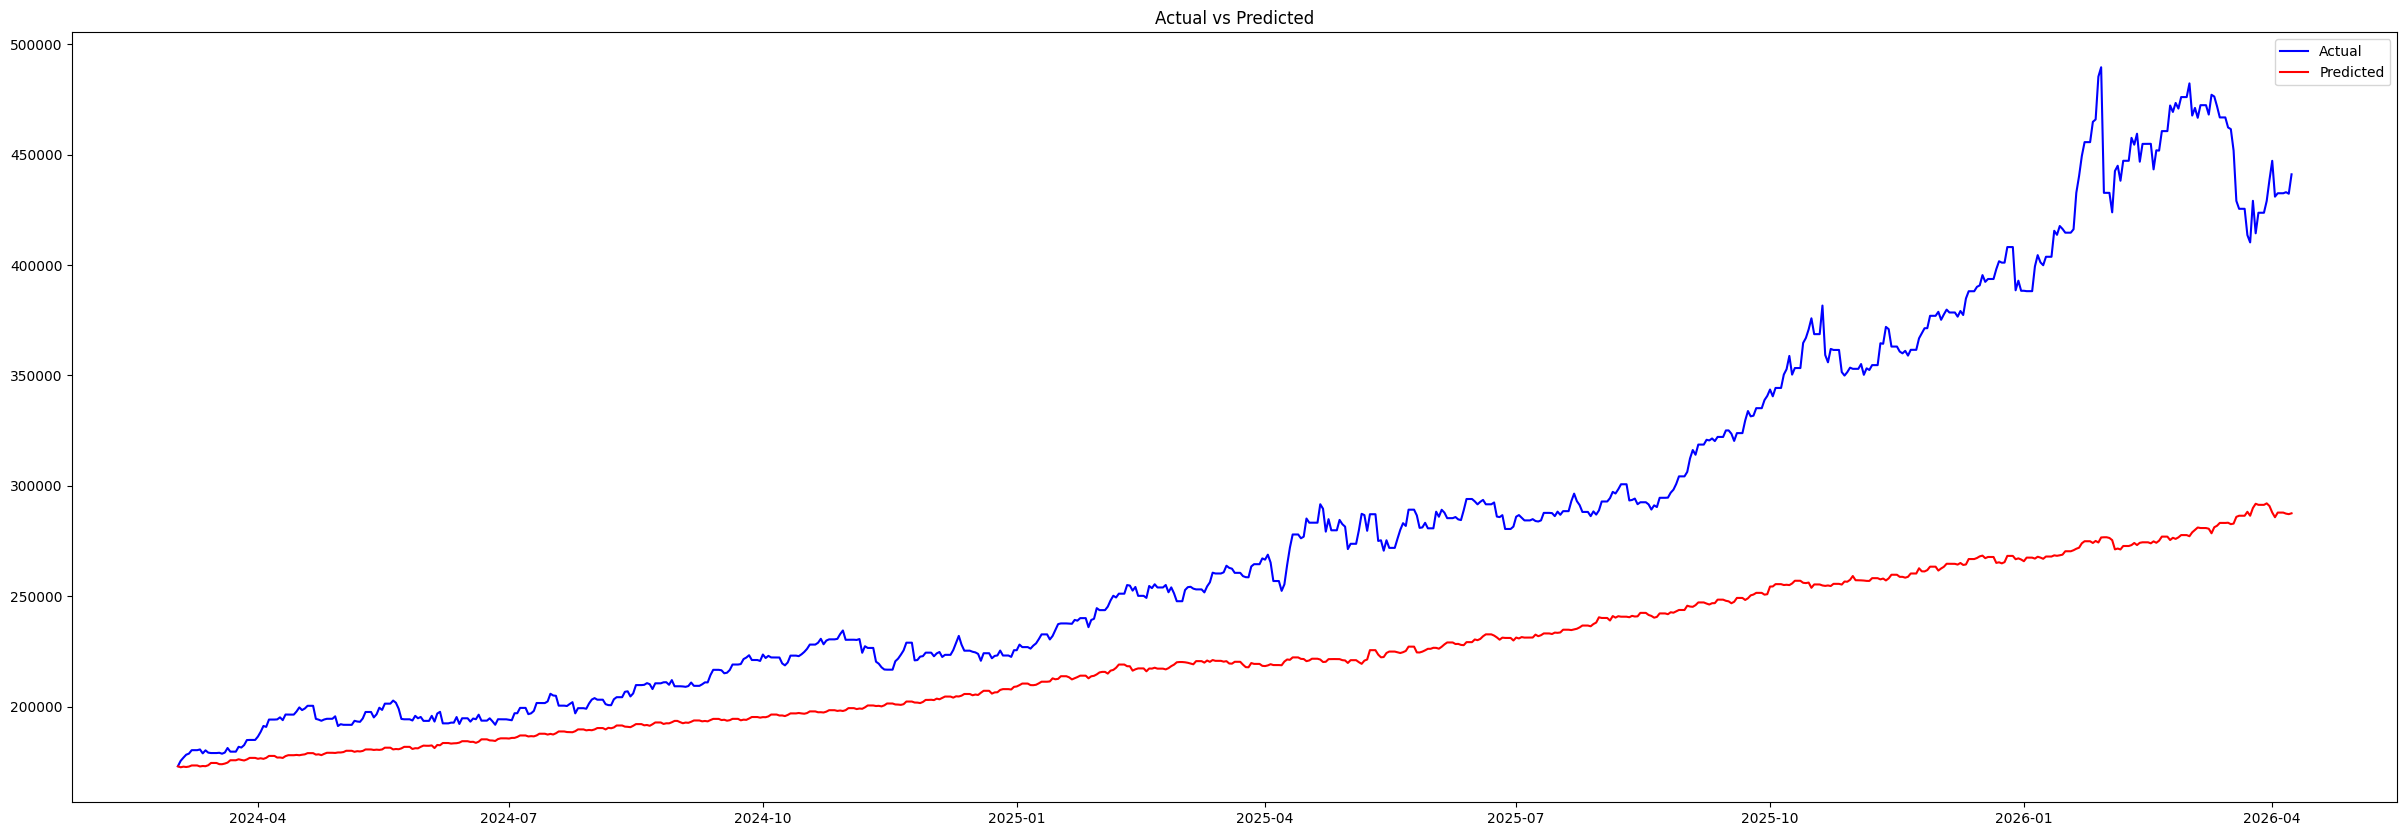

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(prediction, label="Predicted", color="red")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

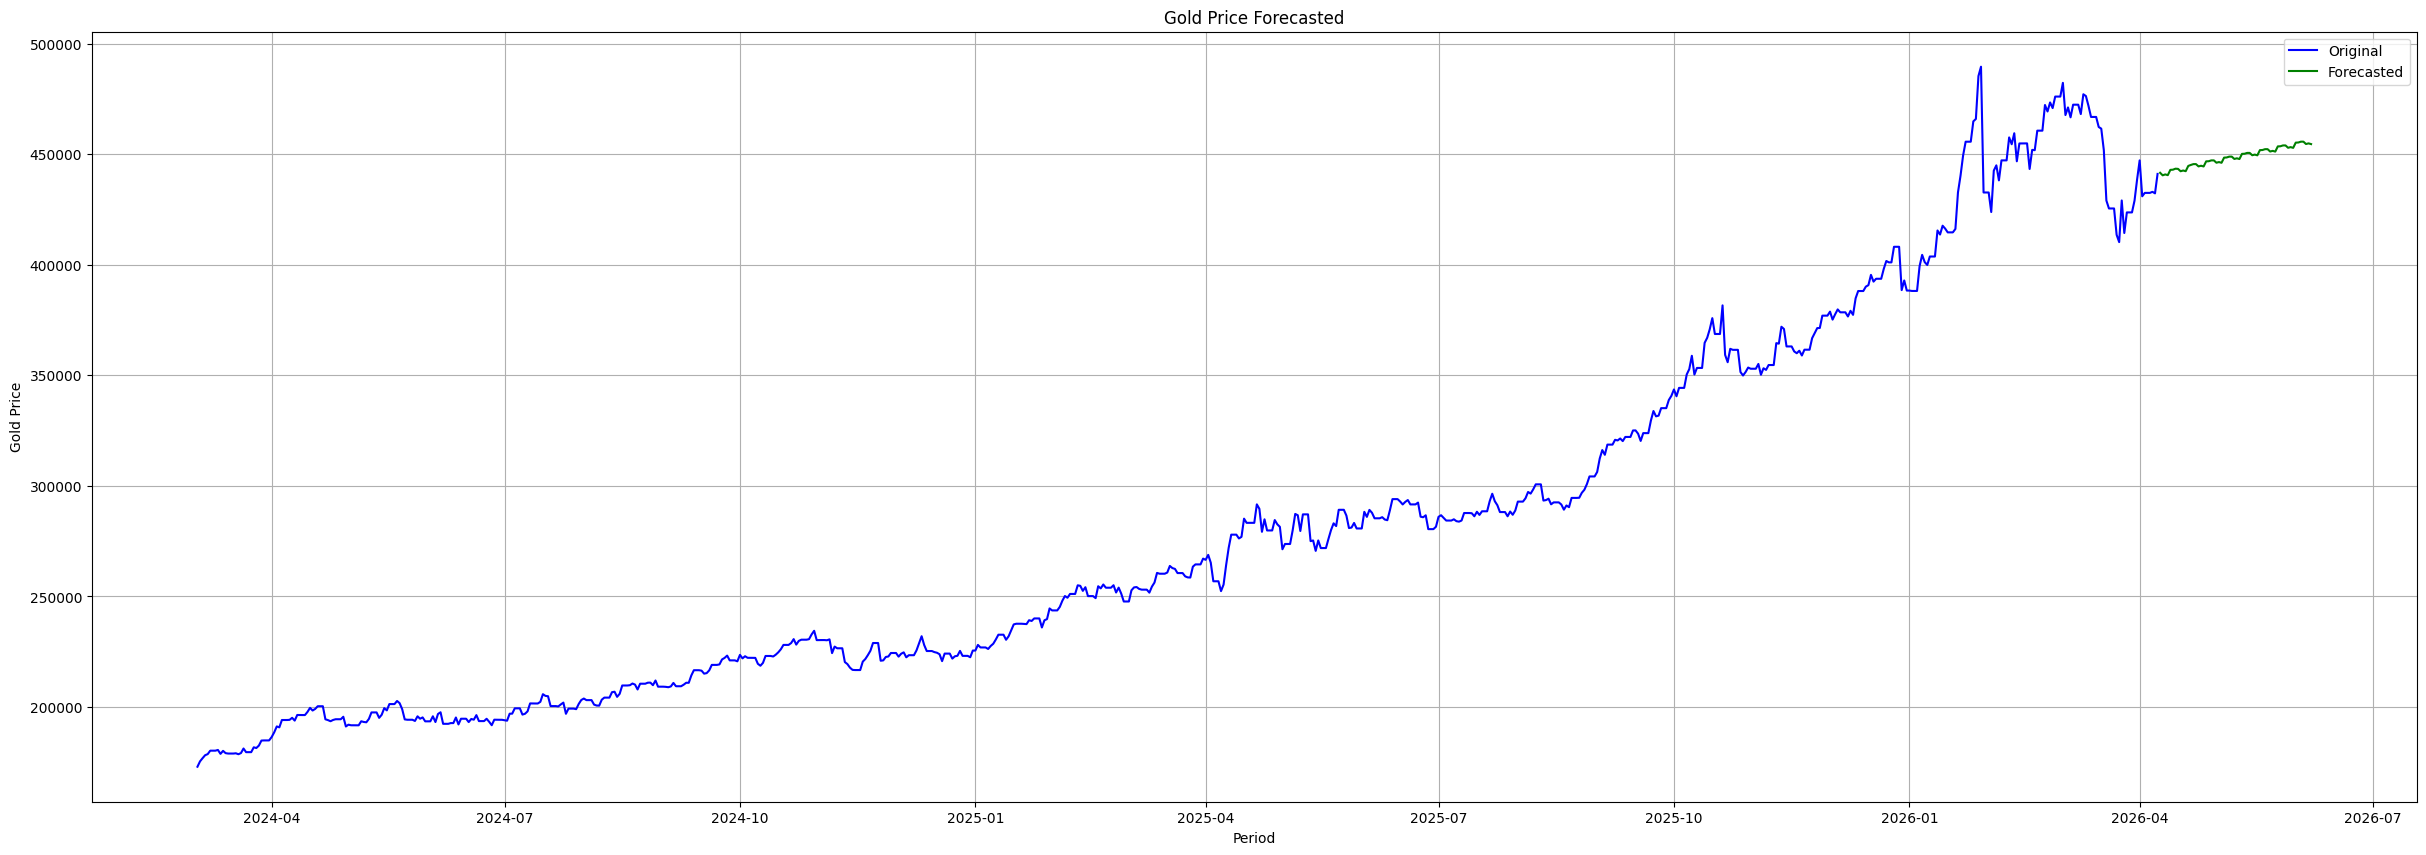

In [ ]:
plt.figure(figsize=(30,10))
plt.plot(y_test.index, y_test, label='Original', color='blue')
plt.plot(future_prices.index, future_prices, label='Forecasted', color='green')
plt.title('Gold Price Forecasted')
plt.xlabel('Period')
plt.ylabel('Gold Price')
plt.legend()
plt.grid()
plt.show()

In [ ]:
future_prices.to_csv('/content/future_prices.csv')